Steps in NLP to train a Model:-
1. Loading Data
2. EDA
3. Data preprocessing
    i. Cleaning the corpus
   ii. Stemming
  iii. All together
   iv. Target encoding
4. Tokens visualization
5. Vectorization
    i. Tunning CountVectorizer
   ii. TF-IDF
  iii. Word Embedding : GloVe
6. Modeling
    i. Naive Bayes DTM
   ii. Naive Bayes TF-IDF
  iii. XGBoost
7. LSTM
8. BERT  
9. NLP: Disaster Tweets
    i. EDA
   ii. Data Preprocessing 

In [2]:
! pip install plotly

In [3]:
!pip install wordcloud

In [4]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import plotly.express as px
from plotly import graph_objs as go
import plotly.figure_factory as ff

from collections import Counter, defaultdict
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

from PIL import Image

import spacy
import random
import os

In [5]:
#Loading data:- Just load the dataset and global variables for colors and so on.
#Defining all our palette colors.
primary_blue =  "#496595"
primary_blue2 = "#85a1c1"
primary_blue3 = "#3f4d63"
primary_grey = "#c6ccd8"
primary_black = "#202022"
primary_bgcolor = "#f4f0ea"
primary_green = px.colors.qualitative.Plotly[2]

In [6]:
df = pd.read_csv("/kaggle/input/datasets/shwetakaliramana/spam-dataset/spam.csv", encoding="latin-1")
df = df.dropna(how="any", axis=1)
df.columns = ['target', 'message']
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   target   5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df['message_len'] = df['message'].apply(lambda x: len(x.split(' ')))
df.head()

,target,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [10]:
max(df['message_len'])

171

In [11]:
min(df['message_len'])

1

In [12]:
df['message'].apply(lambda x: len(x.split('. ')))

0       3
1       2
2       2
3       2
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: message, Length: 5572, dtype: int64

In [13]:
df.head()

,target,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [14]:
# Count the number of Ham and Spam messages
print(df['target'].value_counts())

target
ham     4825
spam     747
Name: count, dtype: int64


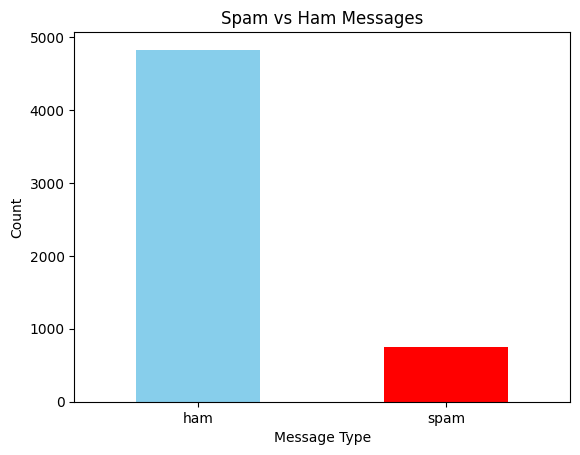

In [15]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'red']
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [16]:
print(df.columns)

Index(['target', 'message', 'message_len'], dtype='object')


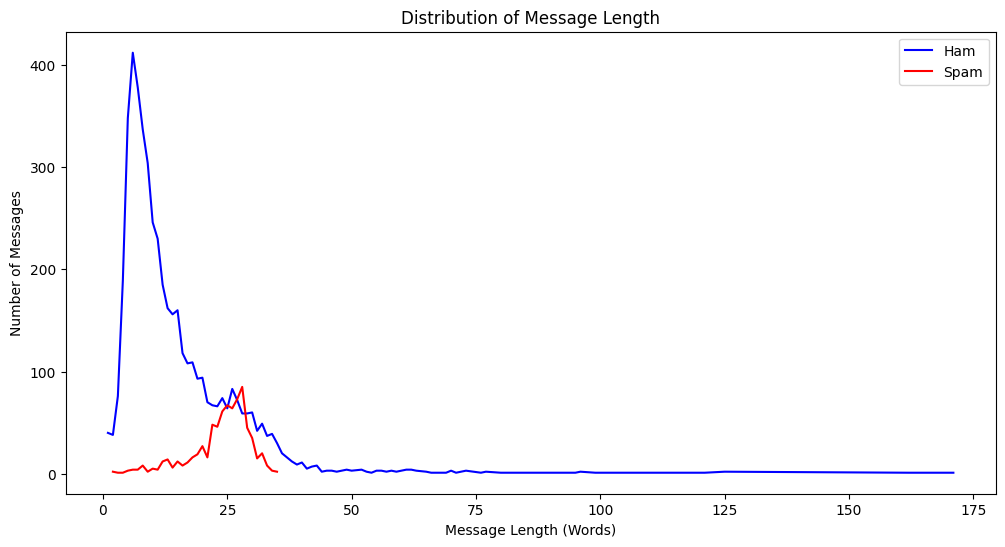

In [17]:
import matplotlib.pyplot as plt

ham_df = df[df['target']=='ham']['message_len'].value_counts().sort_index()
spam_df = df[df['target']=='spam']['message_len'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(ham_df.index, ham_df.values, label='Ham', color='blue')
plt.plot(spam_df.index, spam_df.values, label='Spam', color='red')

plt.xlabel("Message Length (Words)")
plt.ylabel("Number of Messages")
plt.title("Distribution of Message Length")
plt.legend()

plt.show()

In [18]:
#data preprocessing
import re
import string

def clean_text(text):
    """Make text lowercase, remove brackets, links, HTML tags,
    punctuation, newlines, and words containing numbers."""

    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)

    return text

In [19]:
df['message_clean']=df['message'].apply(clean_text)
df.head()

,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah i dont think he goes to usf he lives aroun...


In [20]:
stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

def remove_stopwords(text):
    text = ' '.join([word for word in text.split(' ') if word not in stop_words])
    return text
df['message_clean'] = df['message_clean'].apply(remove_stopwords)
df.head()

,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goes usf lives around though


In [21]:
stemmer = nltk.SnowballStemmer("english")
def stem_words(text):
    text = ' '.join([stemmer.stem(word) for word in text.split(' ')])
    return text
df['message_clean'] = df['message_clean'].apply(stem_words)
df.head()

,target,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,6,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts m...
3,ham,U dun say so early hor... U c already then say...,11,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goe usf live around though


In [23]:
#Target Encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(df['target'])
df['target_encoded'] = le.transform(df['target'])
df.head()

,target,message,message_len,message_clean,target_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...,0
1,ham,Ok lar... Joking wif u oni...,6,ok lar joke wif oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts m...,1
3,ham,U dun say so early hor... U c already then say...,11,dun say earli hor alreadi say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,nah dont think goe usf live around though,0


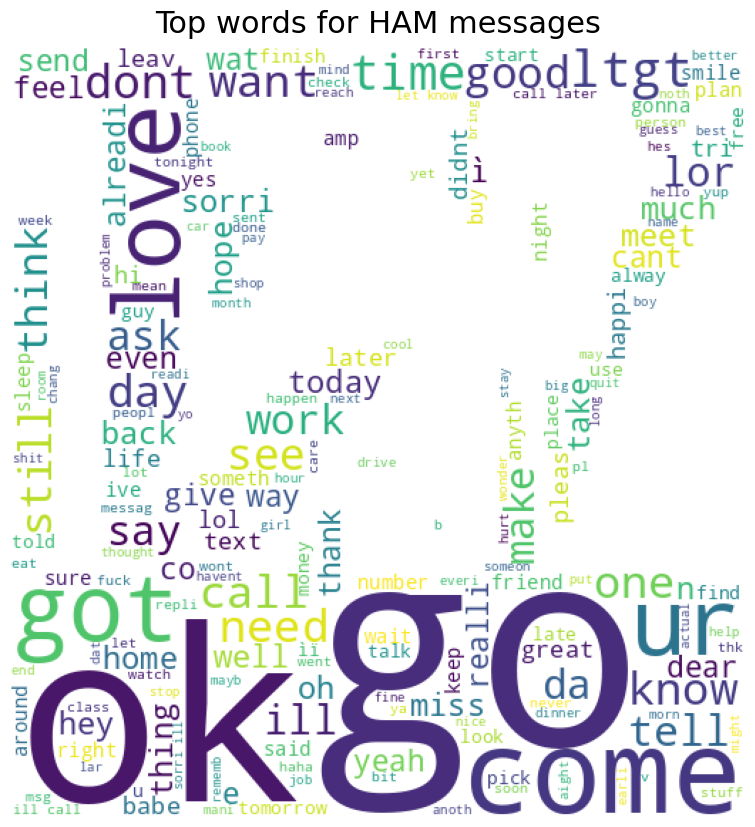

In [29]:
twitter_mask = np.array(Image.open('/kaggle/input/datasets/shwetakaliramana/binaryimage/Screenshot18.png'))
wc=WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join (text for text in df.loc[df['target'] == 'ham', 'message_clean']))
plt.figure(figsize=(18,10))
plt.title('Top words for HAM messages',
         fontdict={'size':22, 'verticalalignment':'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

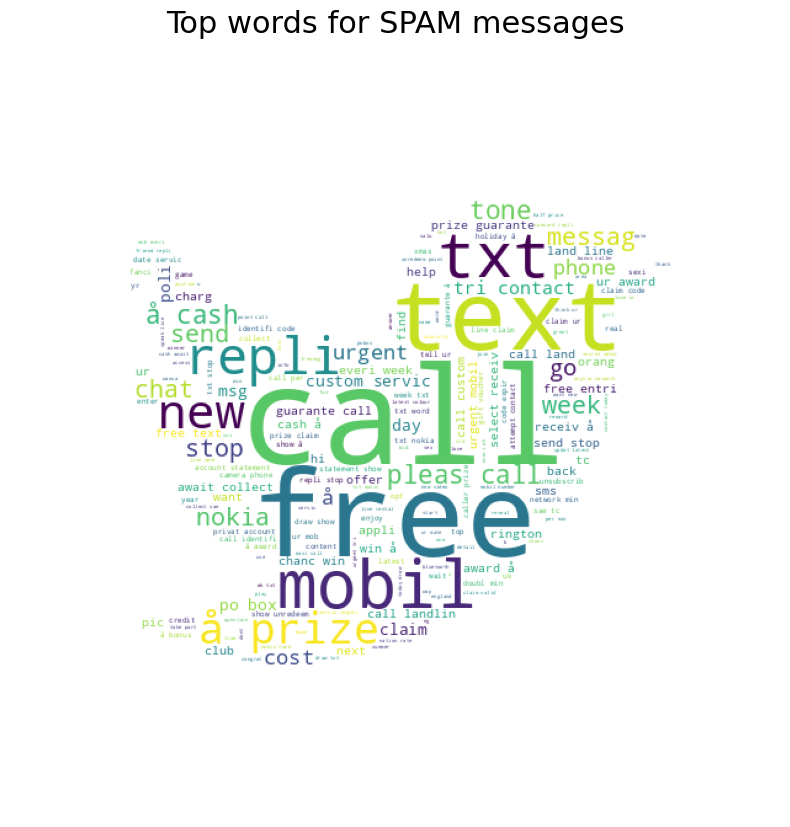

In [30]:
twitter_mask = np.array(Image.open('/kaggle/input/datasets/shwetakaliramana/twitter-mask/twitter_mask4.jpg.jpeg'))
wc=WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join (text for text in df.loc[df['target'] == 'spam', 'message_clean']))
plt.figure(figsize=(18,10))
plt.title('Top words for SPAM messages',
         fontdict={'size':22, 'verticalalignment':'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

In [33]:
x=df['message_clean']
y=df['target_encoded']
print(len(x), len(y))


5572 5572


In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)
print(len(x_train), len(y_train))
print(len(x_test), len(y_test))

4179 4179
1393 1393


In [36]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer()
vect.fit(x_train)

CountVectorizer()

In [41]:
x_train_dtm=vect.transform(x_train)
x_test_dtm=vect.transform(x_test)

In [42]:
x_train_dtm

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 32431 stored elements and shape (4179, 5717)>

In [1]:
vect_tunned = CountVectorizer(stop_words='english', ngram_range=(1,2), min_df=0.01, max_df=0.95)

NameError: name 'CountVectorizer' is not defined

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

x_train_tfidf = tfidf.fit_transform(x_train)

x_test_tfidf = tfidf.transform(x_test)

In [68]:
texts=df['message_clean']
target=df['target_encoded']